  Barcode Damage Detection — Perceptron (MLP) Baseline
  Device     : cpu
  Image size : 64×64 (flattened to 12288 inputs)
  Epochs     : 30
  Save to    : best_barcode_model_perceptron_tuned_v2.pth

Step 1 — Setting up DataLoaders...
  Classes    : ['FAIL', 'PASS']
  Train      : 4200  |  Val: 900  |  Test: 900
  Input size : 12288 (flattened pixels)

Step 2 — Building Perceptron (MLP)...
  Architecture : Input(12288) → 1024 → 1024 → 2
  Total params : 13,639,682
  Optimizer    : AdamW  lr=0.00029  (tuned)
  Weight decay : 0.00084  (tuned)
  Dropout      : 0.35 both layers  (raised to reduce overfitting)
  BatchNorm    : enabled after each layer
  Early stop   : patience=6 epochs

Step 3 — Training...

Epoch 1/30  ------------------------------
  Batch 20/66 | Loss: 0.6721
  Batch 40/66 | Loss: 0.6536
  Batch 60/66 | Loss: 0.6821
  Train → Loss: 0.6590  Acc: 64.1%
  Val   → Loss: 0.5822  Acc: 66.6%
  LR: 0.000290  |  Time: 63.8s
  New best model saved — val acc: 66.6%

Epoch 2/30  ---

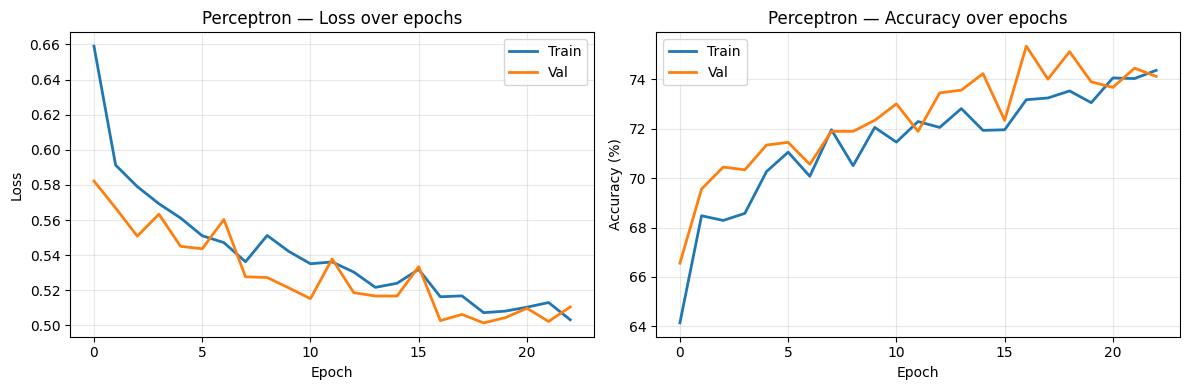


Step 4 — Evaluating on test set...

  Accuracy  : 74.67%
  Precision : 77.39%
  Recall    : 74.67%
  F1 Score  : 73.87%

  Per-class report:
              precision    recall  f1-score   support

        FAIL       0.86      0.57      0.69       439
        PASS       0.69      0.91      0.79       461

    accuracy                           0.75       900
   macro avg       0.78      0.74      0.74       900
weighted avg       0.77      0.75      0.74       900



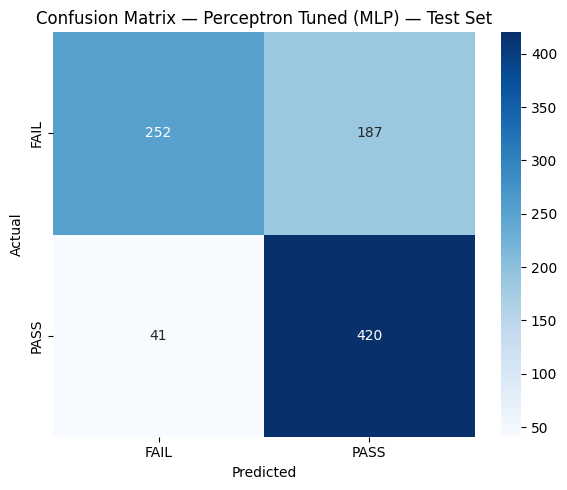

  Confusion matrix saved to confusion_matrix_perceptron.png

  Model Comparison Summary
  Perceptron tuned (MLP)    : 74.7% test accuracy
  ResNet18 (CNN)            : 91.1% test accuracy
  EfficientNet-B0 (default) : 91.3% val accuracy
  EfficientNet-B0 (tuned)   : 92.2% val accuracy

  CNN advantage over MLP    : +16.4%
  This gap shows how much spatial feature detection
  (edges, textures, damage patterns) contributes over
  raw pixel statistics alone.


In [2]:
"""
Barcode Damage Detection — Perceptron (MLP) Baseline
=====================================================
Trains a Multi-Layer Perceptron on the same dataset used for
ResNet18 and EfficientNet-B0, so results can be directly compared.

A perceptron works by:
  1. Flattening each 224×224×3 image into a vector of 150,528 numbers
  2. Passing it through fully-connected (linear) layers
  3. Outputting PASS or FAIL

Unlike CNNs, the perceptron has NO convolutional layers — it cannot
detect spatial patterns like edges, scratches, or textures. Every pixel
is treated as an independent feature with no relationship to its neighbours.

This gives us a useful baseline:
  - If perceptron scores ~70%, CNNs at 92% are genuinely much better
  - If perceptron also scores 92%, the task might just be a colour/brightness problem

Run:
    python train_perceptron.py
"""

import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             classification_report)

# ── Config ────────────────────────────────────────────────────────────────────
DATASET_DIR          = "barcode_dataset_with_fail"
IMG_SIZE             = 64
NUM_WORKERS          = 0
MODEL_SAVE           = "best_barcode_model_perceptron_tuned_v2.pth"
DEVICE               = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Tuned hyperparameters (Optuna — 25 trials on quality-filtered dataset) ───
LEARNING_RATE        = 0.00029
BATCH_SIZE           = 64
WEIGHT_DECAY         = 0.00084
NUM_EPOCHS           = 30       # raised — early stopping will end it when needed

# ── Overfitting fixes ─────────────────────────────────────────────────────────
DROPOUT              = 0.35     # was 0.21/0.18 — increased to close train/val gap
PATIENCE_EARLY_STOP  = 6        # halt if val acc doesn't improve for 6 epochs

print("=" * 60)
print("  Barcode Damage Detection — Perceptron (MLP) Baseline")
print("=" * 60)
print(f"  Device     : {DEVICE}")
print(f"  Image size : {IMG_SIZE}×{IMG_SIZE} (flattened to {IMG_SIZE*IMG_SIZE*3} inputs)")
print(f"  Epochs     : {NUM_EPOCHS}")
print(f"  Save to    : {MODEL_SAVE}")

# ── Step 1: DataLoaders ───────────────────────────────────────────────────────
print("\n" + "="*60)
print("Step 1 — Setting up DataLoaders...")
print("="*60)

# NOTE: We use a smaller image size (64×64) because the MLP input layer
# would need 150,528 neurons for 224×224 — too large for CPU RAM.
# At 64×64 it needs 12,288 neurons which is manageable.
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

train_ds = datasets.ImageFolder(
    os.path.join(DATASET_DIR, "train"),      transform=train_transform)
val_ds   = datasets.ImageFolder(
    os.path.join(DATASET_DIR, "validation"), transform=eval_transform)
test_ds  = datasets.ImageFolder(
    os.path.join(DATASET_DIR, "test"),       transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)

CLASS_NAMES = train_ds.classes   # ['FAIL', 'PASS']
INPUT_SIZE  = IMG_SIZE * IMG_SIZE * 3   # flattened pixel count

print(f"  Classes    : {CLASS_NAMES}")
print(f"  Train      : {len(train_ds)}  |  Val: {len(val_ds)}  |  Test: {len(test_ds)}")
print(f"  Input size : {INPUT_SIZE} (flattened pixels)")

# ── Step 2: Model — Multi-Layer Perceptron ────────────────────────────────────
print("\n" + "="*60)
print("Step 2 — Building Perceptron (MLP)...")
print("="*60)


class BarcodeMLP(nn.Module):
    """
    Tuned Multi-Layer Perceptron — with overfitting fixes applied.

    Architecture:   Input(12288) → 1024 → 1024 → 2
    Dropout:        0.35 both layers (raised from 0.21/0.18 to close train/val gap)
    BatchNorm:      after each linear layer — stabilises training
    Early stopping: halts automatically when val acc stops improving
    Augmentation:   random flip, rotation, crop, colour jitter on training images
    """
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.flatten = nn.Flatten()

        layers = []
        in_features = input_size

        # Layer 1: 12288 → 1024
        layers += [nn.Linear(in_features, 1024), nn.BatchNorm1d(1024),
                   nn.ReLU(), nn.Dropout(DROPOUT)]
        in_features = 1024

        # Layer 2: 1024 → 1024
        layers += [nn.Linear(in_features, 1024), nn.BatchNorm1d(1024),
                   nn.ReLU(), nn.Dropout(DROPOUT)]
        in_features = 1024

        # Output: 1024 → 2 (FAIL / PASS)
        layers.append(nn.Linear(in_features, num_classes))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)


model     = BarcodeMLP(INPUT_SIZE, len(CLASS_NAMES)).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE,
                        weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=4)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"  Architecture : Input({INPUT_SIZE}) → 1024 → 1024 → 2")
print(f"  Total params : {total_params:,}")
print(f"  Optimizer    : AdamW  lr={LEARNING_RATE}  (tuned)")
print(f"  Weight decay : {WEIGHT_DECAY}  (tuned)")
print(f"  Dropout      : {DROPOUT} both layers  (raised to reduce overfitting)")
print(f"  BatchNorm    : enabled after each layer")
print(f"  Early stop   : patience={PATIENCE_EARLY_STOP} epochs")

# ── Step 3: Training Loop ─────────────────────────────────────────────────────
print("\n" + "="*60)
print("Step 3 — Training...")
print("="*60)

history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [],
}
best_val_acc      = 0.0
best_wts_path     = MODEL_SAVE
epochs_no_improve = 0   # early stopping counter

for epoch in range(NUM_EPOCHS):
    t0 = time.time()
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}  " + "-"*30)

    # Training
    model.train()
    run_loss = run_correct = 0
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        preds        = outputs.argmax(dim=1)
        run_loss    += loss.item() * images.size(0)
        run_correct += (preds == labels).sum().item()
        if (batch_idx + 1) % 20 == 0:
            print(f"  Batch {batch_idx+1}/{len(train_loader)} "
                  f"| Loss: {loss.item():.4f}")

    train_loss = run_loss    / len(train_ds)
    train_acc  = run_correct / len(train_ds)

    # Validation
    model.eval()
    val_loss = val_correct = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs     = model(images)
            loss        = criterion(outputs, labels)
            preds       = outputs.argmax(dim=1)
            val_loss   += loss.item() * images.size(0)
            val_correct += (preds == labels).sum().item()

    val_loss /= len(val_ds)
    val_acc   = val_correct / len(val_ds)
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"  Train → Loss: {train_loss:.4f}  Acc: {train_acc*100:.1f}%")
    print(f"  Val   → Loss: {val_loss:.4f}  Acc: {val_acc*100:.1f}%")
    print(f"  LR: {current_lr:.6f}  |  Time: {time.time()-t0:.1f}s")

    if val_acc > best_val_acc:
        best_val_acc      = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), MODEL_SAVE)
        print(f"  New best model saved — val acc: {best_val_acc*100:.1f}%")
    else:
        epochs_no_improve += 1
        print(f"  No improvement ({epochs_no_improve}/{PATIENCE_EARLY_STOP})")

    if epochs_no_improve >= PATIENCE_EARLY_STOP:
        print(f"\n  Early stopping — val acc flat for {PATIENCE_EARLY_STOP} epochs")
        print(f"  Best was {best_val_acc*100:.1f}% — stopping now to avoid overfitting")
        break

print(f"\n  Best val accuracy : {best_val_acc*100:.1f}%")
print(f"  Model saved to    : {MODEL_SAVE}")

# ── Training curves ───────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history["train_loss"], label="Train", linewidth=2)
ax1.plot(history["val_loss"],   label="Val",   linewidth=2)
ax1.set_title("Perceptron — Loss over epochs")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot([a*100 for a in history["train_acc"]], label="Train", linewidth=2)
ax2.plot([a*100 for a in history["val_acc"]],   label="Val",   linewidth=2)
ax2.set_title("Perceptron — Accuracy over epochs")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves_perceptron.png", dpi=150)
plt.show()

# ── Step 4: Test Set Evaluation ───────────────────────────────────────────────
print("\n" + "="*60)
print("Step 4 — Evaluating on test set...")
print("="*60)

model.load_state_dict(torch.load(MODEL_SAVE, map_location=DEVICE))
model.eval()
all_preds = []; all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(DEVICE)
        outputs = model(images)
        preds   = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

acc  = accuracy_score (all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='weighted')
rec  = recall_score   (all_labels, all_preds, average='weighted')
f1   = f1_score       (all_labels, all_preds, average='weighted')

print(f"\n  Accuracy  : {acc*100:.2f}%")
print(f"  Precision : {prec*100:.2f}%")
print(f"  Recall    : {rec*100:.2f}%")
print(f"  F1 Score  : {f1*100:.2f}%")
print("\n  Per-class report:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix — Perceptron Tuned (MLP) — Test Set")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix_perceptron.png", dpi=150)
plt.show()
print("  Confusion matrix saved to confusion_matrix_perceptron.png")

# ── Step 5: Final comparison summary ─────────────────────────────────────────
print("\n" + "="*60)
print("  Model Comparison Summary")
print("="*60)
print(f"  Perceptron tuned (MLP)    : {acc*100:.1f}% test accuracy")
print(f"  ResNet18 (CNN)            : 91.1% test accuracy")
print(f"  EfficientNet-B0 (default) : 91.3% val accuracy")
print(f"  EfficientNet-B0 (tuned)   : 92.2% val accuracy")
print()
gap = (0.911 - acc) * 100
if gap > 0:
    print(f"  CNN advantage over MLP    : +{gap:.1f}%")
    print("  This gap shows how much spatial feature detection")
    print("  (edges, textures, damage patterns) contributes over")
    print("  raw pixel statistics alone.")
else:
    print("  MLP performed surprisingly well!")
    print("  The task may be solvable from pixel statistics alone.")